In [1]:
# ============================================================
# PHASE 5.4B — DNABERT-2 EXTENSION BIOLOGICAL QUICK VALIDATION
# ============================================================

!pip install -q gprofiler-official openpyxl

In [2]:
# ============================================================
# IMPORTS
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from gprofiler import GProfiler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 250)

SEED = 42
np.random.seed(SEED)

In [3]:
# ============================================================
# PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Phase 3 shared dataset
PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE3_DATA_DIR = PHASE3_DIR / "shared_dataset"

# Phase 4.0 biological preparation from old official model
PHASE4_DIR = PROJECT_DIR / "model" / "phase4_biological_validation_preparation"
PHASE4_RESULT_DIR = PHASE4_DIR / "results"
PHASE4_GENE_LIST_DIR = PHASE4_DIR / "gene_lists"

# Phase 4.1 enrichment from old official model
PHASE4_1_DIR = PROJECT_DIR / "model" / "phase4_1_biological_validation_enrichment"
PHASE4_1_RESULT_DIR = PHASE4_1_DIR / "results"

# Phase 5 DNABERT-2 extension
PHASE5_DIR = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
PHASE5_EMBEDDING_DIR = PHASE5_DIR / "embeddings"
PHASE5_RESULT_DIR = PHASE5_DIR / "results"
PHASE5_MODEL_DIR = PHASE5_DIR / "models"

# New output
PHASE5_4B_DIR = PROJECT_DIR / "model" / "phase5_4B_dnabert2_biological_quick_validation"
RESULT_DIR = PHASE5_4B_DIR / "results"
GENE_LIST_DIR = PHASE5_4B_DIR / "gene_lists"
ENRICHMENT_DIR = PHASE5_4B_DIR / "enrichment_results"
FIGURE_DIR = PHASE5_4B_DIR / "figures"
REPORT_DIR = PHASE5_4B_DIR / "reports"
EXCEL_DIR = PHASE5_4B_DIR / "excel"

for folder in [
    PHASE5_4B_DIR,
    RESULT_DIR,
    GENE_LIST_DIR,
    ENRICHMENT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
    EXCEL_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 5.4B output:", PHASE5_4B_DIR)

Mounted at /content/drive
Phase 5.4B output: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation


In [4]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_positive_class_score(model, X):
    """
    Return positive-class score.
    Prefer predict_proba if available.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict(X)


def evaluate_from_score(y_true, y_score, threshold=0.5, model_name="model", dataset_name="test"):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "model": model_name,
        "dataset": dataset_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def assign_error_type(y_true, y_pred):
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 0:
        return "TN"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 1 and y_pred == 0:
        return "FN"
    return "UNKNOWN"


def export_gene_symbol_list(df, output_txt_path, symbol_col="gene_symbol"):
    genes = (
        df[symbol_col]
        .dropna()
        .astype(str)
        .str.strip()
    )
    genes = genes[genes != ""]
    genes = genes.drop_duplicates().tolist()

    with open(output_txt_path, "w") as f:
        for gene in genes:
            f.write(gene + "\n")

    print("Saved:", output_txt_path, "| n =", len(genes))

    return genes


def clean_gene_list_text(x, max_genes=None):
    if pd.isna(x):
        return ""

    genes = str(x).replace("[", "").replace("]", "").replace("'", "").replace(",", ";").split(";")
    genes = [g.strip() for g in genes if g.strip() != ""]

    if max_genes is not None:
        genes = genes[:max_genes]

    return "; ".join(genes)


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df

In [5]:
# ============================================================
# LOAD PHASE 5 OFFICIAL COMBINED PROTBERT + DNABERT-2 MODEL
# ============================================================

official_phase5_model_path = PHASE5_MODEL_DIR / "phase5_3_official_combined_protbert_dnabert2_model.pkl"

assert official_phase5_model_path.exists(), f"Missing model: {official_phase5_model_path}"

phase5_model = joblib.load(official_phase5_model_path)

print("Loaded Phase 5 official model:", official_phase5_model_path)
print(type(phase5_model))

Loaded Phase 5 official model: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/models/phase5_3_official_combined_protbert_dnabert2_model.pkl
<class 'sklearn.pipeline.Pipeline'>


In [6]:
# ============================================================
# LOAD SHARED TEST METADATA + LABELS
# ============================================================

test_meta = pd.read_csv(PHASE3_DATA_DIR / "test_multimodal_metadata_v1.csv")
y_test = np.load(PHASE3_DATA_DIR / "y_test_multimodal_v1.npy")

print("test_meta:", test_meta.shape)
print("y_test:", y_test.shape)

display(test_meta.head())

test_meta: (271, 12)
y_test: (271,)


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol
0,ENSG00000122971,ACADS,1,593,train,ACADS,1,1151,train,True,1,ACADS
1,ENSG00000162104,ADCY9,1,693,train,ADCY9,1,399,train,True,1,ADCY9
2,ENSG00000123146,ADGRE5,0,115,train,ADGRE5,0,880,train,True,0,ADGRE5
3,ENSG00000172594,SMPDL3A,0,1609,test,SMPDL3A,0,617,train,True,0,SMPDL3A
4,ENSG00000163116,STPG2,0,159,train,STPG2,0,207,train,True,0,STPG2


In [7]:
# ============================================================
# LOAD COMBINED PROTBERT + DNABERT-2 TEST FEATURES
# ============================================================

X_test_phase5_path = PHASE5_EMBEDDING_DIR / "X_test_combined_protbert_sw_dnabert2_v1.npy"

assert X_test_phase5_path.exists(), f"Missing: {X_test_phase5_path}"

X_test_phase5 = np.load(X_test_phase5_path)

print("X_test_phase5:", X_test_phase5.shape)

X_test_phase5: (271, 1792)


In [8]:
# ============================================================
# PHASE 5 MODEL PREDICTIONS
# ============================================================

phase5_score = get_positive_class_score(phase5_model, X_test_phase5)
phase5_pred = (phase5_score >= 0.5).astype(int)

phase5_predictions_df = test_meta.copy()
phase5_predictions_df["true_label"] = y_test
phase5_predictions_df["phase5_score"] = phase5_score
phase5_predictions_df["phase5_pred"] = phase5_pred
phase5_predictions_df["phase5_error_type"] = [
    assign_error_type(y, p) for y, p in zip(y_test, phase5_pred)
]
phase5_predictions_df["phase5_correct"] = (
    phase5_predictions_df["true_label"] == phase5_predictions_df["phase5_pred"]
)

phase5_predictions_df = phase5_predictions_df.sort_values(
    by="phase5_score",
    ascending=False
).reset_index(drop=True)

phase5_predictions_df["phase5_rank"] = np.arange(1, len(phase5_predictions_df) + 1)

display(phase5_predictions_df[[
    "phase5_rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase5_score",
    "phase5_pred",
    "phase5_error_type"
]].head(30))

phase5_predictions_path = RESULT_DIR / "phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv"
phase5_predictions_df.to_csv(phase5_predictions_path, index=False)

print("Saved:", phase5_predictions_path)

,phase5_rank,gene_id,gene_symbol,true_label,phase5_score,phase5_pred,phase5_error_type
0,1,ENSG00000053254,FOXN3,1,0.871123,1,TP
1,2,ENSG00000157388,CACNA1D,1,0.860397,1,TP
2,3,ENSG00000151276,MAGI1,1,0.845741,1,TP
3,4,ENSG00000127334,DYRK2,1,0.843176,1,TP
4,5,ENSG00000128683,GAD1,1,0.836452,1,TP
5,6,ENSG00000171105,INSR,1,0.832819,1,TP
6,7,ENSG00000276644,DACH1,1,0.820353,1,TP
7,8,ENSG00000146267,FAXC,0,0.804802,1,FP
8,9,ENSG00000162104,ADCY9,1,0.791051,1,TP
9,10,ENSG00000108091,CCDC6,0,0.788497,1,FP


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv


In [9]:
# ============================================================
# VERIFY PHASE 5 OFFICIAL TEST METRICS
# ============================================================

phase5_metrics = evaluate_from_score(
    y_true=y_test,
    y_score=phase5_score,
    threshold=0.5,
    model_name="Combined ProtBERT-SW + DNABERT-2 SVM RBF",
    dataset_name="test"
)

phase5_metrics_df = pd.DataFrame([phase5_metrics])
phase5_metrics_df = round_numeric_columns(phase5_metrics_df, 4)

display(phase5_metrics_df)

phase5_metrics_path = RESULT_DIR / "phase5_4B_phase5_official_test_metrics.csv"
phase5_metrics_df.to_csv(phase5_metrics_path, index=False)

print("Saved:", phase5_metrics_path)

,model,dataset,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Combined ProtBERT-SW + DNABERT-2 SVM RBF,test,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.7568,0.7447,0.3433,94,42,47,88


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_official_test_metrics.csv


In [10]:
# ============================================================
# EXTRACT PHASE 5 TOP GENE LISTS
# ============================================================

TOP_N = 50

phase5_top50_df = phase5_predictions_df.sort_values(
    by="phase5_score",
    ascending=False
).head(TOP_N).copy()

phase5_true_positives_df = phase5_predictions_df[
    phase5_predictions_df["phase5_error_type"] == "TP"
].sort_values(
    by="phase5_score",
    ascending=False
).copy()

phase5_false_positives_df = phase5_predictions_df[
    phase5_predictions_df["phase5_error_type"] == "FP"
].sort_values(
    by="phase5_score",
    ascending=False
).copy()

phase5_false_negatives_df = phase5_predictions_df[
    phase5_predictions_df["phase5_error_type"] == "FN"
].sort_values(
    by="phase5_score",
    ascending=True
).copy()

phase5_true_negatives_df = phase5_predictions_df[
    phase5_predictions_df["phase5_error_type"] == "TN"
].sort_values(
    by="phase5_score",
    ascending=True
).copy()

print("Top 50:", phase5_top50_df.shape)
print("TP:", phase5_true_positives_df.shape)
print("FP:", phase5_false_positives_df.shape)
print("FN:", phase5_false_negatives_df.shape)
print("TN:", phase5_true_negatives_df.shape)

display(phase5_top50_df[[
    "phase5_rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase5_score",
    "phase5_error_type"
]].head(50))

phase5_top50_df.to_csv(GENE_LIST_DIR / "phase5_top50_combined_protbert_dnabert2_predictions.csv", index=False)
phase5_true_positives_df.to_csv(GENE_LIST_DIR / "phase5_true_positives.csv", index=False)
phase5_false_positives_df.to_csv(GENE_LIST_DIR / "phase5_false_positives.csv", index=False)
phase5_false_negatives_df.to_csv(GENE_LIST_DIR / "phase5_false_negatives.csv", index=False)
phase5_true_negatives_df.to_csv(GENE_LIST_DIR / "phase5_true_negatives.csv", index=False)

phase5_top50_symbols = export_gene_symbol_list(
    phase5_top50_df,
    GENE_LIST_DIR / "gene_symbols_phase5_top50.txt"
)

phase5_tp_symbols = export_gene_symbol_list(
    phase5_true_positives_df,
    GENE_LIST_DIR / "gene_symbols_phase5_true_positives.txt"
)

phase5_fp_symbols = export_gene_symbol_list(
    phase5_false_positives_df,
    GENE_LIST_DIR / "gene_symbols_phase5_false_positives.txt"
)

phase5_fn_symbols = export_gene_symbol_list(
    phase5_false_negatives_df,
    GENE_LIST_DIR / "gene_symbols_phase5_false_negatives.txt"
)

Top 50: (50, 18)
TP: (88, 18)
FP: (42, 18)
FN: (47, 18)
TN: (94, 18)


,phase5_rank,gene_id,gene_symbol,true_label,phase5_score,phase5_error_type
0,1,ENSG00000053254,FOXN3,1,0.871123,TP
1,2,ENSG00000157388,CACNA1D,1,0.860397,TP
2,3,ENSG00000151276,MAGI1,1,0.845741,TP
3,4,ENSG00000127334,DYRK2,1,0.843176,TP
4,5,ENSG00000128683,GAD1,1,0.836452,TP
5,6,ENSG00000171105,INSR,1,0.832819,TP
6,7,ENSG00000276644,DACH1,1,0.820353,TP
7,8,ENSG00000146267,FAXC,0,0.804802,FP
8,9,ENSG00000162104,ADCY9,1,0.791051,TP
9,10,ENSG00000108091,CCDC6,0,0.788497,FP


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_top50.txt | n = 50
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_true_positives.txt | n = 88
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_false_positives.txt | n = 42
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_false_negatives.txt | n = 47


In [11]:
# ============================================================
# LOAD OLD PHASE 3.1 OFFICIAL PREDICTIONS
# ============================================================

old_phase3_predictions_path = PHASE4_RESULT_DIR / "phase4_0B_official_combined_svm_all_test_predictions.csv"

assert old_phase3_predictions_path.exists(), f"Missing: {old_phase3_predictions_path}"

old_phase3_predictions_df = pd.read_csv(old_phase3_predictions_path)

print("old_phase3_predictions_df:", old_phase3_predictions_df.shape)

display(old_phase3_predictions_df.head())

old_phase3_predictions_df: (271, 17)


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,true_label,combined_svm_score,combined_svm_pred,combined_error_type,combined_correct
0,ENSG00000053254,FOXN3,1,671,train,FOXN3,1,193,train,True,1,FOXN3,1,0.884630,1,TP,True
1,ENSG00000276644,DACH1,1,549,train,DACH1,1,919,train,True,1,DACH1,1,0.841229,1,TP,True
2,ENSG00000090266,NDUFB2,1,1719,test,NDUFB2,1,930,train,True,1,NDUFB2,1,0.831156,1,TP,True
3,ENSG00000006468,ETV1,1,1701,test,ETV1,1,540,train,True,1,ETV1,1,0.824098,1,TP,True
4,ENSG00000162992,NEUROD1,1,1726,test,NEUROD1,1,795,train,True,1,NEUROD1,1,0.818462,1,TP,True


In [12]:
# ============================================================
# STANDARDIZE OLD PHASE 3 COLUMNS
# ============================================================

old_cols = old_phase3_predictions_df.columns.tolist()

# Expected from Phase 4.0:
# combined_svm_score, combined_svm_pred, combined_error_type
assert "gene_id" in old_phase3_predictions_df.columns
assert "combined_svm_score" in old_phase3_predictions_df.columns
assert "combined_svm_pred" in old_phase3_predictions_df.columns
assert "combined_error_type" in old_phase3_predictions_df.columns

old_phase3_small_df = old_phase3_predictions_df[[
    "gene_id",
    "combined_svm_score",
    "combined_svm_pred",
    "combined_error_type"
]].copy()

old_phase3_small_df = old_phase3_small_df.rename(columns={
    "combined_svm_score": "phase3_score",
    "combined_svm_pred": "phase3_pred",
    "combined_error_type": "phase3_error_type"
})

phase5_compare_df = phase5_predictions_df.merge(
    old_phase3_small_df,
    on="gene_id",
    how="left"
)

missing_old = phase5_compare_df["phase3_score"].isna().sum()
print("Missing old predictions:", missing_old)
assert missing_old == 0

phase5_compare_df["phase3_correct"] = (
    phase5_compare_df["true_label"] == phase5_compare_df["phase3_pred"]
)

phase5_compare_df["phase5_correct"] = (
    phase5_compare_df["true_label"] == phase5_compare_df["phase5_pred"]
)

def assign_phase5_vs_phase3_group(row):
    if row["phase3_correct"] and row["phase5_correct"]:
        return "both_correct"
    if (not row["phase3_correct"]) and (not row["phase5_correct"]):
        return "both_wrong"
    if row["phase5_correct"] and (not row["phase3_correct"]):
        return "phase5_correct_phase3_wrong"
    if row["phase3_correct"] and (not row["phase5_correct"]):
        return "phase3_correct_phase5_wrong"
    return "unknown"

phase5_compare_df["phase5_vs_phase3_error_group"] = phase5_compare_df.apply(
    assign_phase5_vs_phase3_group,
    axis=1
)

phase5_compare_df["score_delta_phase5_minus_phase3"] = (
    phase5_compare_df["phase5_score"] - phase5_compare_df["phase3_score"]
)

display(phase5_compare_df[[
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase3_score",
    "phase5_score",
    "score_delta_phase5_minus_phase3",
    "phase3_error_type",
    "phase5_error_type",
    "phase5_vs_phase3_error_group"
]].head())

compare_path = RESULT_DIR / "phase5_4B_phase5_vs_phase3_prediction_comparison.csv"
phase5_compare_df.to_csv(compare_path, index=False)

print("Saved:", compare_path)

Missing old predictions: 0


,gene_id,gene_symbol,true_label,phase3_score,phase5_score,score_delta_phase5_minus_phase3,phase3_error_type,phase5_error_type,phase5_vs_phase3_error_group
0,ENSG00000053254,FOXN3,1,0.884630,0.871123,-0.013508,TP,TP,both_correct
1,ENSG00000157388,CACNA1D,1,0.798518,0.860397,0.061880,TP,TP,both_correct
2,ENSG00000151276,MAGI1,1,0.693629,0.845741,0.152112,TP,TP,both_correct
3,ENSG00000127334,DYRK2,1,0.805801,0.843176,0.037375,TP,TP,both_correct
4,ENSG00000128683,GAD1,1,0.813424,0.836452,0.023028,TP,TP,both_correct


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_vs_phase3_prediction_comparison.csv


In [13]:
# ============================================================
# PHASE 5 VS PHASE 3 ERROR GROUP SUMMARY
# ============================================================

error_group_summary_df = (
    phase5_compare_df["phase5_vs_phase3_error_group"]
    .value_counts()
    .rename_axis("error_group")
    .reset_index(name="n_genes")
)

error_group_summary_df["percentage"] = (
    error_group_summary_df["n_genes"] / len(phase5_compare_df) * 100
)

error_group_by_label_df = (
    phase5_compare_df
    .groupby(["phase5_vs_phase3_error_group", "true_label"])
    .size()
    .reset_index(name="n_genes")
)

display(error_group_summary_df)
display(error_group_by_label_df)

error_group_summary_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_vs_phase3_error_group_summary.csv",
    index=False
)

error_group_by_label_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_vs_phase3_error_group_by_label.csv",
    index=False
)

,error_group,n_genes,percentage
0,both_correct,168,61.992620
1,both_wrong,75,27.675277
2,phase3_correct_phase5_wrong,14,5.166052
3,phase5_correct_phase3_wrong,14,5.166052


,phase5_vs_phase3_error_group,true_label,n_genes
0,both_correct,0,87
1,both_correct,1,81
2,both_wrong,0,33
3,both_wrong,1,42
4,phase3_correct_phase5_wrong,0,9
5,phase3_correct_phase5_wrong,1,5
6,phase5_correct_phase3_wrong,0,7
7,phase5_correct_phase3_wrong,1,7


In [14]:
# ============================================================
# EXTRACT PHASE 5 RESCUED / LOST GENES RELATIVE TO PHASE 3
# ============================================================

phase5_rescued_genes_df = phase5_compare_df[
    phase5_compare_df["phase5_vs_phase3_error_group"] == "phase5_correct_phase3_wrong"
].sort_values(
    by=["true_label", "phase5_score"],
    ascending=[False, False]
).copy()

phase5_lost_genes_df = phase5_compare_df[
    phase5_compare_df["phase5_vs_phase3_error_group"] == "phase3_correct_phase5_wrong"
].sort_values(
    by=["true_label", "phase3_score"],
    ascending=[False, False]
).copy()

both_wrong_phase5_phase3_df = phase5_compare_df[
    phase5_compare_df["phase5_vs_phase3_error_group"] == "both_wrong"
].copy()

print("Phase 5 rescued genes:", phase5_rescued_genes_df.shape)
print("Phase 5 lost genes:", phase5_lost_genes_df.shape)
print("Both wrong:", both_wrong_phase5_phase3_df.shape)

display(phase5_rescued_genes_df[[
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase3_score",
    "phase5_score",
    "score_delta_phase5_minus_phase3",
    "phase3_error_type",
    "phase5_error_type"
]].head(50))

display(phase5_lost_genes_df[[
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase3_score",
    "phase5_score",
    "score_delta_phase5_minus_phase3",
    "phase3_error_type",
    "phase5_error_type"
]].head(50))

phase5_rescued_genes_df.to_csv(GENE_LIST_DIR / "phase5_rescued_genes_vs_phase3.csv", index=False)
phase5_lost_genes_df.to_csv(GENE_LIST_DIR / "phase5_lost_genes_vs_phase3.csv", index=False)
both_wrong_phase5_phase3_df.to_csv(GENE_LIST_DIR / "phase5_phase3_both_wrong_genes.csv", index=False)

phase5_rescued_symbols = export_gene_symbol_list(
    phase5_rescued_genes_df,
    GENE_LIST_DIR / "gene_symbols_phase5_rescued_vs_phase3.txt"
)

phase5_lost_symbols = export_gene_symbol_list(
    phase5_lost_genes_df,
    GENE_LIST_DIR / "gene_symbols_phase5_lost_vs_phase3.txt"
)

Phase 5 rescued genes: (14, 24)
Phase 5 lost genes: (14, 24)
Both wrong: (75, 24)


,gene_id,gene_symbol,true_label,phase3_score,phase5_score,score_delta_phase5_minus_phase3,phase3_error_type,phase5_error_type
107,ENSG00000101391,CDK5RAP1,1,0.494782,0.552102,0.057320,FN,TP
108,ENSG00000147684,NDUFB9,1,0.461754,0.549536,0.087782,FN,TP
110,ENSG00000178409,BEND3,1,0.481322,0.543925,0.062603,FN,TP
111,ENSG00000163636,PSMD6,1,0.387487,0.540116,0.152629,FN,TP
118,ENSG00000165623,UCMA,1,0.492378,0.525763,0.033385,FN,TP
122,ENSG00000132205,EMILIN2,1,0.416122,0.521708,0.105586,FN,TP
128,ENSG00000164512,ANKRD55,1,0.339436,0.500000,0.160564,FN,TP
131,ENSG00000090989,EXOC1,0,0.597733,0.481145,-0.116588,FP,TN
132,ENSG00000130713,EXOSC2,0,0.572591,0.481110,-0.091480,FP,TN
142,ENSG00000128040,SPINK2,0,0.509539,0.456201,-0.053338,FP,TN


,gene_id,gene_symbol,true_label,phase3_score,phase5_score,score_delta_phase5_minus_phase3,phase3_error_type,phase5_error_type
150,ENSG00000186010,NDUFA13,1,0.694361,0.440820,-0.253541,TP,FN
136,ENSG00000150347,ARID5B,1,0.659305,0.468087,-0.191218,TP,FN
139,ENSG00000101057,MYBL2,1,0.638690,0.465138,-0.173552,TP,FN
133,ENSG00000121653,MAPK8IP1,1,0.546722,0.481046,-0.065676,TP,FN
156,ENSG00000134640,MTNR1B,1,0.500000,0.423323,-0.076677,TP,FN
101,ENSG00000184986,TMEM121,0,0.493134,0.571231,0.078098,TN,FP
127,ENSG00000182450,KCNK4,0,0.487189,0.500000,0.012811,TN,FP
125,ENSG00000276950,GSTT4,0,0.485300,0.512845,0.027545,TN,FP
105,ENSG00000100426,ZBED4,0,0.482295,0.569404,0.087109,TN,FP
129,ENSG00000077327,SPAG6,0,0.476395,0.500000,0.023605,TN,FP


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_rescued_vs_phase3.txt | n = 14
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/gene_lists/gene_symbols_phase5_lost_vs_phase3.txt | n = 14


In [15]:
# ============================================================
# TOP 50 OVERLAP: PHASE 5 VS PHASE 3
# ============================================================

old_top50_path = PHASE4_1_RESULT_DIR / "phase4_1_top50_gene_curated_validation_status.csv"

assert old_top50_path.exists(), f"Missing: {old_top50_path}"

old_top50_df = pd.read_csv(old_top50_path)

old_top50_symbols = set(old_top50_df["gene_symbol"].dropna().astype(str).str.upper())
phase5_top50_symbols_set = set(phase5_top50_df["gene_symbol"].dropna().astype(str).str.upper())

shared_top50 = sorted(list(old_top50_symbols & phase5_top50_symbols_set))
new_only_top50 = sorted(list(phase5_top50_symbols_set - old_top50_symbols))
old_only_top50 = sorted(list(old_top50_symbols - phase5_top50_symbols_set))

top50_overlap_summary_df = pd.DataFrame([{
    "old_phase3_top50_n": len(old_top50_symbols),
    "phase5_top50_n": len(phase5_top50_symbols_set),
    "shared_top50_n": len(shared_top50),
    "phase5_new_only_top50_n": len(new_only_top50),
    "old_only_top50_n": len(old_only_top50),
    "jaccard_overlap": len(shared_top50) / len(old_top50_symbols | phase5_top50_symbols_set),
    "shared_top50_genes": ";".join(shared_top50),
    "phase5_new_only_top50_genes": ";".join(new_only_top50),
    "old_only_top50_genes": ";".join(old_only_top50),
}])

display(top50_overlap_summary_df)

top50_overlap_summary_df.to_csv(
    RESULT_DIR / "phase5_4B_top50_overlap_phase5_vs_phase3.csv",
    index=False
)

# Mark each Phase 5 top50 gene as shared/new
phase5_top50_annotated_df = phase5_top50_df.copy()
phase5_top50_annotated_df["gene_symbol_upper"] = phase5_top50_annotated_df["gene_symbol"].astype(str).str.upper()
phase5_top50_annotated_df["top50_status_vs_phase3"] = phase5_top50_annotated_df["gene_symbol_upper"].apply(
    lambda g: "shared_with_phase3_top50" if g in old_top50_symbols else "new_in_phase5_top50"
)

display(phase5_top50_annotated_df[[
    "phase5_rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase5_score",
    "phase5_error_type",
    "top50_status_vs_phase3"
]].head(50))

phase5_top50_annotated_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_top50_annotated_vs_phase3.csv",
    index=False
)

,old_phase3_top50_n,phase5_top50_n,shared_top50_n,phase5_new_only_top50_n,old_only_top50_n,jaccard_overlap,shared_top50_genes,phase5_new_only_top50_genes,old_only_top50_genes
0,50,50,39,11,11,0.639344,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1


,phase5_rank,gene_id,gene_symbol,true_label,phase5_score,phase5_error_type,top50_status_vs_phase3
0,1,ENSG00000053254,FOXN3,1,0.871123,TP,shared_with_phase3_top50
1,2,ENSG00000157388,CACNA1D,1,0.860397,TP,shared_with_phase3_top50
2,3,ENSG00000151276,MAGI1,1,0.845741,TP,new_in_phase5_top50
3,4,ENSG00000127334,DYRK2,1,0.843176,TP,shared_with_phase3_top50
4,5,ENSG00000128683,GAD1,1,0.836452,TP,shared_with_phase3_top50
5,6,ENSG00000171105,INSR,1,0.832819,TP,shared_with_phase3_top50
6,7,ENSG00000276644,DACH1,1,0.820353,TP,shared_with_phase3_top50
7,8,ENSG00000146267,FAXC,0,0.804802,FP,shared_with_phase3_top50
8,9,ENSG00000162104,ADCY9,1,0.791051,TP,shared_with_phase3_top50
9,10,ENSG00000108091,CCDC6,0,0.788497,FP,shared_with_phase3_top50


In [16]:
# ============================================================
# CURATED T2D-RELATED GENE SETS
# Same structure as Phase 4.1, extend manually if needed.
# ============================================================

curated_gene_sets = {
    "known_T2D_GWAS_or_monogenic_related": [
        "TCF7L2", "PPARG", "KCNJ11", "ABCC8", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "MTNR1B", "KCNQ1", "WFS1",
        "JAZF1", "THADA", "NOTCH2", "ADCY5", "IRS1", "GCK", "GCKR",
        "PDX1", "NEUROD1", "HNF1A", "HNF1B", "HNF4A", "PAX4", "INSR"
    ],

    "insulin_secretion_beta_cell": [
        "ABCC8", "KCNJ11", "GCK", "PDX1", "NEUROD1", "MAFA", "NKX2-2",
        "NKX6-1", "INS", "INSR", "SLC30A8", "CACNA1D", "CACNA1C",
        "GLP1R", "DPP4", "GAD1", "GAD2", "PCSK1", "PCSK2"
    ],

    "glucose_metabolism_transport": [
        "SLC2A1", "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2", "GCK", "G6PC",
        "G6PC2", "HK1", "HK2", "PFKM", "PKM", "LDHA", "LDHB",
        "GYS1", "GYS2", "PYGL", "PYGM"
    ],

    "lipid_metabolism_adipose": [
        "PPARG", "PPARA", "FABP4", "ADIPOQ", "LEP", "LEPR", "LPL",
        "APOA1", "APOA5", "APOB", "APOE", "SCD", "SCD5", "FASN",
        "ACACA", "ACACB", "CPT1A", "CPT2"
    ],

    "mitochondrial_oxphos": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA7", "NDUFA9", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFC2", "NDUFV1", "NDUFS1", "NDUFS2",
        "COX4I1", "COX5A", "ATP5F1A", "ATP5F1B", "UQCRC1", "UQCRC2"
    ],

    "inflammation_stress": [
        "TNF", "IL6", "IL1B", "NFKB1", "NFKBIA", "RELA", "JUN", "FOS",
        "STAT3", "SOCS3", "CRP", "MCP1", "CCL2", "TLR4"
    ]
}


def compute_overlap_with_curated_sets(query_genes, query_name, curated_sets):
    query_set = set([str(g).upper() for g in query_genes if str(g).strip() != ""])

    records = []

    for set_name, curated_genes in curated_sets.items():
        curated_set = set([str(g).upper() for g in curated_genes])
        overlap = sorted(list(query_set & curated_set))

        records.append({
            "query_gene_list": query_name,
            "curated_set": set_name,
            "n_query_genes": len(query_set),
            "n_curated_genes": len(curated_set),
            "n_overlap": len(overlap),
            "overlap_fraction_query": len(overlap) / len(query_set) if len(query_set) > 0 else 0,
            "overlap_genes": ";".join(overlap)
        })

    return pd.DataFrame(records)

In [17]:
# ============================================================
# CURATED OVERLAP FOR PHASE 5 GENE LISTS
# ============================================================

phase5_gene_lists = {
    "phase5_top50": phase5_top50_symbols,
    "phase5_true_positives": phase5_tp_symbols,
    "phase5_false_positives": phase5_fp_symbols,
    "phase5_false_negatives": phase5_fn_symbols,
    "phase5_rescued_vs_phase3": phase5_rescued_symbols,
    "phase5_lost_vs_phase3": phase5_lost_symbols,
}

overlap_results = []

for list_name, genes in phase5_gene_lists.items():
    overlap_df = compute_overlap_with_curated_sets(
        query_genes=genes,
        query_name=list_name,
        curated_sets=curated_gene_sets
    )
    overlap_results.append(overlap_df)

phase5_curated_overlap_df = pd.concat(overlap_results, ignore_index=True)

phase5_curated_overlap_df = phase5_curated_overlap_df.sort_values(
    by=["n_overlap", "overlap_fraction_query"],
    ascending=False
).reset_index(drop=True)

display(phase5_curated_overlap_df)

phase5_curated_overlap_path = RESULT_DIR / "phase5_4B_curated_t2d_gene_set_overlap.csv"
phase5_curated_overlap_df.to_csv(phase5_curated_overlap_path, index=False)

print("Saved:", phase5_curated_overlap_path)

,query_gene_list,curated_set,n_query_genes,n_curated_genes,n_overlap,overlap_fraction_query,overlap_genes
0,phase5_true_positives,insulin_secretion_beta_cell,88,19,8,0.090909,ABCC8;CACNA1D;DPP4;GAD1;INSR;KCNJ11;NEUROD1;PDX1
1,phase5_true_positives,mitochondrial_oxphos,88,20,8,0.090909,NDUFA2;NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFB3;NDUFC2;NDUFV1
2,phase5_true_positives,known_T2D_GWAS_or_monogenic_related,88,28,7,0.079545,ABCC8;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1
3,phase5_top50,known_T2D_GWAS_or_monogenic_related,50,28,5,0.100000,HHEX;IGF2BP2;INSR;NEUROD1;PDX1
4,phase5_top50,insulin_secretion_beta_cell,50,19,5,0.100000,CACNA1D;GAD1;INSR;NEUROD1;PDX1
5,phase5_false_negatives,known_T2D_GWAS_or_monogenic_related,47,28,3,0.063830,MTNR1B;PAX4;THADA
6,phase5_top50,mitochondrial_oxphos,50,20,2,0.040000,NDUFB2;NDUFV1
7,phase5_true_positives,glucose_metabolism_transport,88,18,2,0.022727,SLC5A1;SLC5A2
8,phase5_lost_vs_phase3,known_T2D_GWAS_or_monogenic_related,14,28,1,0.071429,MTNR1B
9,phase5_lost_vs_phase3,mitochondrial_oxphos,14,20,1,0.071429,NDUFA13


Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_curated_t2d_gene_set_overlap.csv


In [18]:
# ============================================================
# ANNOTATE PHASE 5 TOP 50 WITH CURATED SUPPORT
# ============================================================

gene_to_curated_sets = defaultdict(list)

for set_name, genes in curated_gene_sets.items():
    for gene in genes:
        gene_to_curated_sets[str(gene).upper()].append(set_name)

phase5_top50_annotated_df["curated_t2d_related_sets"] = phase5_top50_annotated_df["gene_symbol_upper"].apply(
    lambda g: ";".join(gene_to_curated_sets.get(g, []))
)

phase5_top50_annotated_df["has_curated_t2d_support"] = (
    phase5_top50_annotated_df["curated_t2d_related_sets"] != ""
)

display(phase5_top50_annotated_df[[
    "phase5_rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase5_score",
    "phase5_error_type",
    "top50_status_vs_phase3",
    "has_curated_t2d_support",
    "curated_t2d_related_sets"
]].head(50))

phase5_top50_annotated_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_top50_curated_validation_status.csv",
    index=False
)

phase5_top50_support_summary_df = pd.DataFrame([{
    "n_top50_genes": len(phase5_top50_annotated_df),
    "n_true_positive": int((phase5_top50_annotated_df["phase5_error_type"] == "TP").sum()),
    "n_false_positive": int((phase5_top50_annotated_df["phase5_error_type"] == "FP").sum()),
    "n_with_curated_t2d_support": int(phase5_top50_annotated_df["has_curated_t2d_support"].sum()),
    "pct_with_curated_t2d_support": float(phase5_top50_annotated_df["has_curated_t2d_support"].mean() * 100),
    "supported_genes": ";".join(
        phase5_top50_annotated_df.loc[
            phase5_top50_annotated_df["has_curated_t2d_support"],
            "gene_symbol"
        ].astype(str).tolist()
    )
}])

display(phase5_top50_support_summary_df)

phase5_top50_support_summary_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_top50_curated_support_summary.csv",
    index=False
)

,phase5_rank,gene_id,gene_symbol,true_label,phase5_score,phase5_error_type,top50_status_vs_phase3,has_curated_t2d_support,curated_t2d_related_sets
0,1,ENSG00000053254,FOXN3,1,0.871123,TP,shared_with_phase3_top50,False,
1,2,ENSG00000157388,CACNA1D,1,0.860397,TP,shared_with_phase3_top50,True,insulin_secretion_beta_cell
2,3,ENSG00000151276,MAGI1,1,0.845741,TP,new_in_phase5_top50,False,
3,4,ENSG00000127334,DYRK2,1,0.843176,TP,shared_with_phase3_top50,False,
4,5,ENSG00000128683,GAD1,1,0.836452,TP,shared_with_phase3_top50,True,insulin_secretion_beta_cell
5,6,ENSG00000171105,INSR,1,0.832819,TP,shared_with_phase3_top50,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
6,7,ENSG00000276644,DACH1,1,0.820353,TP,shared_with_phase3_top50,False,
7,8,ENSG00000146267,FAXC,0,0.804802,FP,shared_with_phase3_top50,False,
8,9,ENSG00000162104,ADCY9,1,0.791051,TP,shared_with_phase3_top50,False,
9,10,ENSG00000108091,CCDC6,0,0.788497,FP,shared_with_phase3_top50,False,


,n_top50_genes,n_true_positive,n_false_positive,n_with_curated_t2d_support,pct_with_curated_t2d_support,supported_genes
0,50,43,7,10,20.0,CACNA1D;GAD1;INSR;NDUFV1;NDUFB2;HHEX;SCD5;NEUROD1;PDX1;IGF2BP2


In [19]:
# ============================================================
# BIOLOGICAL KEYWORD GROUPS FOR ENRICHMENT SCORING
# ============================================================

keyword_groups = {
    "diabetes_glucose_insulin": [
        "diabetes", "insulin", "glucose", "glycemic", "glycaemic",
        "glycolysis", "gluconeogenesis", "glucagon", "pancreatic",
        "pancreas", "islet", "beta cell", "beta-cell", "β-cell",
        "secretion", "homeostasis"
    ],

    "lipid_metabolism": [
        "lipid", "fatty acid", "cholesterol", "triglyceride",
        "lipoprotein", "adipose", "adipocyte", "ppar", "sterol"
    ],

    "mitochondria_energy": [
        "mitochond", "oxidative phosphorylation", "electron transport",
        "respiratory chain", "atp", "nad", "nadh", "oxidoreductase",
        "energy metabolism", "oxidation"
    ],

    "inflammation_immune": [
        "inflamm", "immune", "cytokine", "interleukin", "nf-kappa",
        "tnf", "macrophage", "leukocyte", "response to stress"
    ],

    "signaling_regulation": [
        "pi3k", "akt", "mapk", "ampk", "mtor", "wnt", "tgf",
        "calcium", "camp", "kinase", "phosphorylation",
        "transcription", "regulation of gene expression"
    ],

    "development_beta_cell": [
        "development", "differentiation", "endocrine", "neuron",
        "neurogenesis", "pancreas development", "islet development"
    ]
}


def score_biological_relevance(term_name):
    if pd.isna(term_name):
        return 0, []

    text = str(term_name).lower()

    matched_groups = []

    for group_name, keywords in keyword_groups.items():
        for kw in keywords:
            if kw.lower() in text:
                matched_groups.append(group_name)
                break

    matched_groups = sorted(list(set(matched_groups)))
    score = len(matched_groups)

    return score, matched_groups

In [20]:
# ============================================================
# RUN G:PROFILER ENRICHMENT
# ============================================================

gp = GProfiler(return_dataframe=True)

ENRICHMENT_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC", "WP", "HP"]


def run_gprofiler_enrichment(
    gene_list,
    list_name,
    organism="hsapiens",
    sources=None,
    user_threshold=0.05
):
    if sources is None:
        sources = ENRICHMENT_SOURCES

    clean_genes = [
        str(g).strip()
        for g in gene_list
        if pd.notna(g) and str(g).strip() != ""
    ]
    clean_genes = list(dict.fromkeys(clean_genes))

    print("=" * 100)
    print("Running enrichment:", list_name, "| n =", len(clean_genes))

    if len(clean_genes) < 3:
        print("Skipped: fewer than 3 genes.")
        return pd.DataFrame()

    try:
        result_df = gp.profile(
            organism=organism,
            query=clean_genes,
            sources=sources,
            user_threshold=user_threshold,
            significance_threshold_method="g_SCS",
            no_evidences=False
        )

        if result_df is None or result_df.empty:
            print("No significant enrichment.")
            return pd.DataFrame()

        result_df = result_df.copy()
        result_df["gene_list_name"] = list_name
        result_df["input_n_genes"] = len(clean_genes)
        result_df["input_genes"] = ";".join(clean_genes)

        result_df["minus_log10_p_value"] = -np.log10(
            result_df["p_value"].replace(0, np.nextafter(0, 1))
        )

        relevance_scores = result_df["name"].apply(score_biological_relevance)
        result_df["t2d_relevance_score"] = relevance_scores.apply(lambda x: x[0])
        result_df["matched_biological_groups"] = relevance_scores.apply(lambda x: ";".join(x[1]))

        if "intersections" in result_df.columns:
            result_df["intersection_size"] = result_df["intersections"].apply(
                lambda x: len(x) if isinstance(x, list) else 0
            )
        else:
            result_df["intersection_size"] = np.nan

        result_df = result_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).reset_index(drop=True)

        print("Significant terms:", result_df.shape[0])

        return result_df

    except Exception as e:
        print("Failed:", list_name)
        print(repr(e))
        return pd.DataFrame()

In [21]:
# ============================================================
# ENRICHMENT FOR SELECTED PHASE 5 LISTS
# ============================================================

phase5_enrichment_gene_lists = {
    "phase5_top50": phase5_top50_symbols,
    "phase5_true_positives": phase5_tp_symbols,
    "phase5_rescued_vs_phase3": phase5_rescued_symbols,
    "phase5_false_positives": phase5_fp_symbols,
    "phase5_false_negatives": phase5_fn_symbols,
}

phase5_enrichment_results = {}

for list_name, genes in phase5_enrichment_gene_lists.items():
    result_df = run_gprofiler_enrichment(
        gene_list=genes,
        list_name=list_name,
        organism="hsapiens",
        sources=ENRICHMENT_SOURCES,
        user_threshold=0.05
    )

    phase5_enrichment_results[list_name] = result_df

    out_path = ENRICHMENT_DIR / f"gprofiler_enrichment_{list_name}.csv"
    result_df.to_csv(out_path, index=False)

    print("Saved:", out_path)

Running enrichment: phase5_top50 | n = 50
Significant terms: 43
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/enrichment_results/gprofiler_enrichment_phase5_top50.csv
Running enrichment: phase5_true_positives | n = 88
Significant terms: 148
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/enrichment_results/gprofiler_enrichment_phase5_true_positives.csv
Running enrichment: phase5_rescued_vs_phase3 | n = 14
No significant enrichment.
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/enrichment_results/gprofiler_enrichment_phase5_rescued_vs_phase3.csv
Running enrichment: phase5_false_positives | n = 42
No significant enrichment.
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/enrichment_results/gprofiler_enrichment_phase5_false_positives.csv
Running enrichment: phase5_false_negatives | n 

In [22]:
# ============================================================
# COMBINE PHASE 5 ENRICHMENT RESULTS
# ============================================================

non_empty = [
    df for df in phase5_enrichment_results.values()
    if df is not None and not df.empty
]

if len(non_empty) > 0:
    phase5_all_enrichment_df = pd.concat(non_empty, ignore_index=True)
else:
    phase5_all_enrichment_df = pd.DataFrame()

print("phase5_all_enrichment_df:", phase5_all_enrichment_df.shape)

if not phase5_all_enrichment_df.empty:
    display(phase5_all_enrichment_df.head(30))

phase5_all_enrichment_df.to_csv(
    RESULT_DIR / "phase5_4B_all_gprofiler_enrichment_results.csv",
    index=False
)

phase5_all_enrichment_df: (194, 22)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences,gene_list_name,input_n_genes,input_genes,minus_log10_p_value,t2d_relevance_score,matched_biological_groups
0,GO:MF,GO:0001228,"DNA-binding transcription activator activity, RNA polymerase II-specific",0.000024,True,"""A DNA-binding transcription factor activity that activates or increases transcription of specific gene sets transcribed by RNA polymerase II."" [GOC:aruk, GOC:txnOH-2018, PMID:20737563, PMID:27145859]",431,48,10,20208,0.208333,0.023202,query_1,"[GO:0000981, GO:0001216]","[NFAT5, MEIS1, BCL11B, TCF12, HHEX, ETV1, NEUROD1, TFAP2B, ISL1, EBF2]","[[IDA], [IBA, IEA], [IEA], [IDA], [IMP], [IDA], [IDA, IEA], [IDA, ISS, IBA, IEA], [IEA], [IEA]]",phase5_top50,50,FOXN3;CACNA1D;MAGI1;DYRK2;GAD1;INSR;DACH1;FAXC;ADCY9;CCDC6;PAXIP1;NFAT5;NDUFV1;MEIS1;BCL11B;GALNT10;TCF12;NDUFB2;CHRNA1;PTPRM;RHBDL3;MRC2;CPEB3;ADRB1;TUBB4A;HHEX;DNMT3A;NT5C2;NSD3;PRDM5;SCD5;ACADS;PARP8;ETV1;IGSF21;L3MBTL3;GLRA1;NCALD;NEUROD1;ZC3...,4.620037,1,signaling_regulation
1,GO:MF,GO:0001216,DNA-binding transcription activator activity,0.000027,True,"""A DNA-binding transcription factor activity that activates or increases transcription of specific gene sets."" [GOC:txnOH-2018]",437,48,10,20208,0.208333,0.022883,query_1,[GO:0003700],"[NFAT5, MEIS1, BCL11B, TCF12, HHEX, ETV1, NEUROD1, TFAP2B, ISL1, EBF2]","[[IDA], [IBA, IEA], [IEA], [IDA], [IMP], [IDA], [IDA, IEA], [IDA, ISS, IBA, IEA], [IEA], [IEA]]",phase5_top50,50,FOXN3;CACNA1D;MAGI1;DYRK2;GAD1;INSR;DACH1;FAXC;ADCY9;CCDC6;PAXIP1;NFAT5;NDUFV1;MEIS1;BCL11B;GALNT10;TCF12;NDUFB2;CHRNA1;PTPRM;RHBDL3;MRC2;CPEB3;ADRB1;TUBB4A;HHEX;DNMT3A;NT5C2;NSD3;PRDM5;SCD5;ACADS;PARP8;ETV1;IGSF21;L3MBTL3;GLRA1;NCALD;NEUROD1;ZC3...,4.563881,1,signaling_regulation
2,GO:MF,GO:0000981,"DNA-binding transcription factor activity, RNA polymerase II-specific",0.000085,True,"""A DNA-binding transcription factor activity that modulates the transcription of specific gene sets transcribed by RNA polymerase II."" [GOC:txnOH-2018]",1309,48,15,20208,0.312500,0.011459,query_1,[GO:0003700],"[FOXN3, DACH1, NFAT5, MEIS1, BCL11B, TCF12, HHEX, PRDM5, ETV1, NEUROD1, TFAP2B, ISL1, TSHZ3, EBF2, PDX1]","[[ISA], [IDA, IBA, IEA], [IDA, ISA, IBA], [ISA, IBA, IEA], [IEA], [IDA, ISA, IBA], [IDA, IMP, ISA, IEA], [IDA], [IDA, ISA, IBA], [IDA, ISA, IBA, IEA], [IDA, ISS, ISA, IBA, IEA], [IDA, ISA, IBA, IEA], [ISA, IBA], [ISA, IBA, IEA], [ISA, IBA, IEA]]",phase5_top50,50,FOXN3;CACNA1D;MAGI1;DYRK2;GAD1;INSR;DACH1;FAXC;ADCY9;CCDC6;PAXIP1;NFAT5;NDUFV1;MEIS1;BCL11B;GALNT10;TCF12;NDUFB2;CHRNA1;PTPRM;RHBDL3;MRC2;CPEB3;ADRB1;TUBB4A;HHEX;DNMT3A;NT5C2;NSD3;PRDM5;SCD5;ACADS;PARP8;ETV1;IGSF21;L3MBTL3;GLRA1;NCALD;NEUROD1;ZC3...,4.072905,1,signaling_regulation
3,GO:MF,GO:0003700,DNA-binding transcription factor activity,0.000192,True,"""A transcription regulator activity that modulates transcription of gene sets via selective and non-covalent binding to a specific double-stranded genomic DNA sequence (sometimes referred to as a motif) within a cis-regulatory region. Regulatory ...",1395,48,15,20208,0.312500,0.010753,query_1,[GO:0140110],"[FOXN3, DACH1, NFAT5, MEIS1, BCL11B, TCF12, HHEX, PRDM5, ETV1, NEUROD1, TFAP2B, ISL1, TSHZ3, EBF2, PDX1]","[[ISA, IBA, IEA], [IDA, IBA, IEA], [IDA, ISA, IBA, TAS, IEA], [ISA, IBA, IEA], [IBA, IEA], [IDA, ISA, IBA], [IDA, IMP, ISA, IEA], [IDA, IBA], [IDA, ISA, IBA, TAS, IEA], [IDA, ISA, IBA, IEA], [IDA, ISS, ISA, IBA, NAS, IEA], [IDA, ISA, IBA, IEA], [...",phase5_top50,50,FOXN3;CACNA1D;MAGI1;DYRK2;GAD1;INSR;DACH1;FAXC;ADCY9;CCDC6;PAXIP1;NFAT5;NDUFV1;MEIS1;BCL11B;GALNT10;TCF12;NDUFB2;CHRNA1;PTPRM;RHBDL3;MRC2;CPEB3;ADRB1;TUBB4A;HHEX;DNMT3A;NT5C2;NSD3;PRDM5;SCD5;ACADS;PARP8;ETV1;IGSF21;L3MBTL3;GLRA1;NCALD;NEUROD1;ZC3...,3.716677,1,signaling_regulation
4,GO:MF,GO:0000976,transcription cis-regulatory region binding,0.000226,True,"""Binding to a specific sequence of DNA that is par

In [23]:
# ============================================================
# T2D-RELEVANT TERMS
# ============================================================

if not phase5_all_enrichment_df.empty:
    phase5_t2d_relevant_terms_df = phase5_all_enrichment_df[
        phase5_all_enrichment_df["t2d_relevance_score"] > 0
    ].copy()

    phase5_t2d_relevant_terms_df = phase5_t2d_relevant_terms_df.sort_values(
        by=["gene_list_name", "t2d_relevance_score", "p_value"],
        ascending=[True, False, True]
    ).reset_index(drop=True)

    display(phase5_t2d_relevant_terms_df[[
        "gene_list_name",
        "source",
        "native",
        "name",
        "p_value",
        "t2d_relevance_score",
        "matched_biological_groups",
        "intersection_size"
    ]].head(100))

else:
    phase5_t2d_relevant_terms_df = pd.DataFrame()
    print("No enrichment result.")

phase5_t2d_relevant_terms_df.to_csv(
    RESULT_DIR / "phase5_4B_t2d_relevant_enrichment_terms.csv",
    index=False
)

,gene_list_name,source,native,name,p_value,t2d_relevance_score,matched_biological_groups,intersection_size
0,phase5_false_negatives,GO:BP,GO:0070663,regulation of leukocyte proliferation,0.037982,1,inflammation_immune,6
1,phase5_top50,GO:MF,GO:0001228,"DNA-binding transcription activator activity, RNA polymerase II-specific",0.000024,1,signaling_regulation,10
2,phase5_top50,GO:MF,GO:0001216,DNA-binding transcription activator activity,0.000027,1,signaling_regulation,10
3,phase5_top50,GO:MF,GO:0000981,"DNA-binding transcription factor activity, RNA polymerase II-specific",0.000085,1,signaling_regulation,15
4,phase5_top50,GO:MF,GO:0003700,DNA-binding transcription factor activity,0.000192,1,signaling_regulation,15
...,...,...,...,...,...,...,...,...
59,phase5_true_positives,HP,HP:0001952,Glucose intolerance,0.030328,1,diabetes_glucose_insulin,11
60,phase5_true_positives,GO:BP,GO:0007275,multicellular organism development,0.031846,1,development_beta_cell,37
61,phase5_true_positives,HP,HP:0006476,Abnormality of the pancreatic islet cells,0.033816,1,diabetes_glucose_insulin,4
62,phase5_true_positives,GO:MF,GO:0000976,transcription cis-regulatory region binding,0.048798,1,signaling_regulation,17


In [24]:
# ============================================================
# PHASE 5 ENRICHMENT SUMMARY BY GENE LIST
# ============================================================

summary_records = []

for list_name, genes in phase5_enrichment_gene_lists.items():
    df = phase5_enrichment_results.get(list_name, pd.DataFrame())

    if df is None or df.empty:
        summary_records.append({
            "gene_list_name": list_name,
            "n_input_genes": len(genes),
            "n_significant_terms": 0,
            "n_t2d_relevant_terms": 0,
            "best_p_value": np.nan,
            "top_term": None,
            "top_t2d_relevant_term": None
        })
        continue

    t2d_df = df[df["t2d_relevance_score"] > 0].copy()

    top_term = df.sort_values("p_value").iloc[0]["name"]

    if not t2d_df.empty:
        top_t2d_term = t2d_df.sort_values(
            by=["t2d_relevance_score", "p_value"],
            ascending=[False, True]
        ).iloc[0]["name"]
    else:
        top_t2d_term = None

    summary_records.append({
        "gene_list_name": list_name,
        "n_input_genes": len(genes),
        "n_significant_terms": df.shape[0],
        "n_t2d_relevant_terms": t2d_df.shape[0],
        "best_p_value": df["p_value"].min(),
        "top_term": top_term,
        "top_t2d_relevant_term": top_t2d_term
    })

phase5_enrichment_summary_df = pd.DataFrame(summary_records).sort_values(
    by=["n_t2d_relevant_terms", "n_significant_terms"],
    ascending=False
).reset_index(drop=True)

display(phase5_enrichment_summary_df)

phase5_enrichment_summary_df.to_csv(
    RESULT_DIR / "phase5_4B_enrichment_summary_by_gene_list.csv",
    index=False
)

,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term
0,phase5_true_positives,88,148,47,5.060767e-11,active monoatomic ion transmembrane transporter activity,Oxidative phosphorylation
1,phase5_top50,50,43,16,1.241294e-05,cis-regulatory region sequence-specific DNA binding,"DNA-binding transcription activator activity, RNA polymerase II-specific"
2,phase5_false_negatives,47,3,1,3.798158e-02,regulation of leukocyte proliferation,regulation of leukocyte proliferation
3,phase5_rescued_vs_phase3,14,0,0,NaN,None,None
4,phase5_false_positives,42,0,0,NaN,None,None


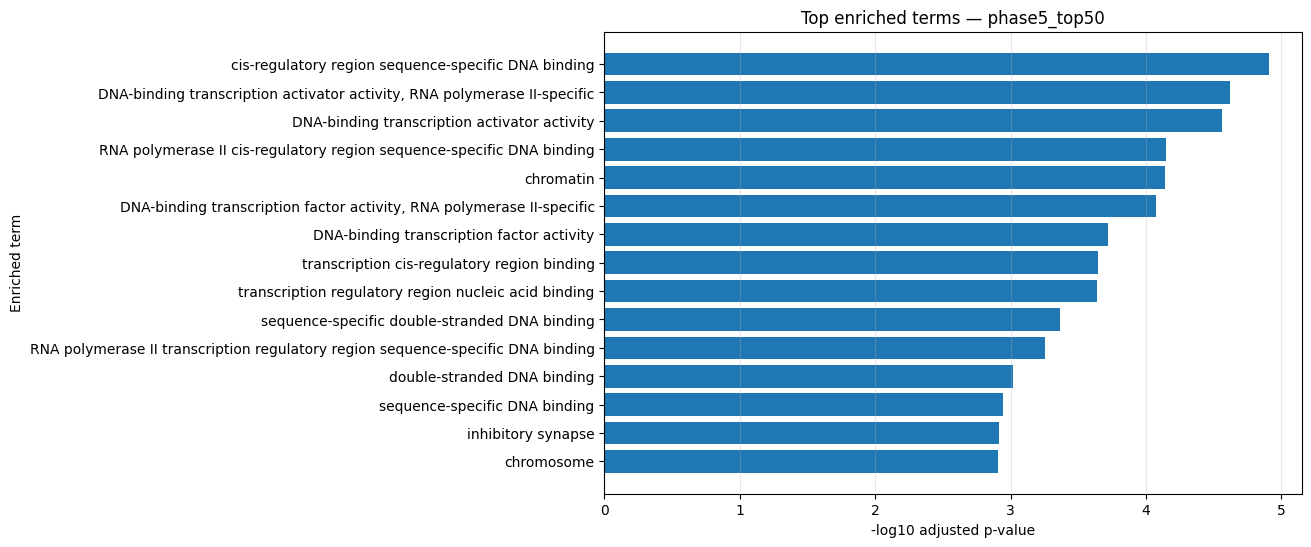

Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/figures/phase5_4B_top50_enrichment_terms.png


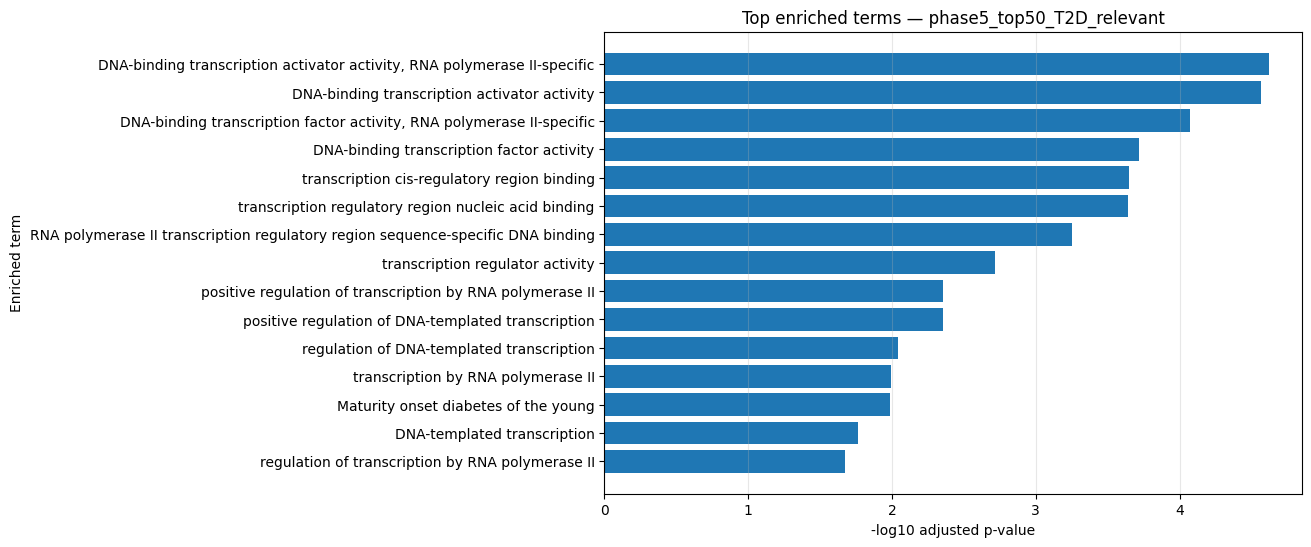

Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/figures/phase5_4B_top50_t2d_relevant_terms.png


In [25]:
# ============================================================
# PLOT ENRICHMENT TERMS
# ============================================================

def plot_top_enrichment_terms(df, list_name, top_n=15, output_path=None):
    if df is None or df.empty:
        print("No terms to plot for:", list_name)
        return

    plot_df = df.sort_values("p_value").head(top_n).copy()

    if "minus_log10_p_value" not in plot_df.columns:
        plot_df["minus_log10_p_value"] = -np.log10(
            plot_df["p_value"].replace(0, np.nextafter(0, 1))
        )

    plot_df = plot_df.sort_values("minus_log10_p_value", ascending=True)

    plt.figure(figsize=(9, max(5, 0.4 * len(plot_df))))
    plt.barh(plot_df["name"].astype(str), plot_df["minus_log10_p_value"])
    plt.xlabel("-log10 adjusted p-value")
    plt.ylabel("Enriched term")
    plt.title(f"Top enriched terms — {list_name}")
    plt.grid(axis="x", alpha=0.3)

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

    if output_path is not None:
        print("Saved:", output_path)


phase5_top50_enrichment_df = phase5_enrichment_results.get("phase5_top50", pd.DataFrame())

plot_top_enrichment_terms(
    df=phase5_top50_enrichment_df,
    list_name="phase5_top50",
    top_n=15,
    output_path=FIGURE_DIR / "phase5_4B_top50_enrichment_terms.png"
)

if not phase5_top50_enrichment_df.empty:
    phase5_top50_t2d_terms_df = phase5_top50_enrichment_df[
        phase5_top50_enrichment_df["t2d_relevance_score"] > 0
    ].copy()

    plot_top_enrichment_terms(
        df=phase5_top50_t2d_terms_df,
        list_name="phase5_top50_T2D_relevant",
        top_n=15,
        output_path=FIGURE_DIR / "phase5_4B_top50_t2d_relevant_terms.png"
    )
else:
    phase5_top50_t2d_terms_df = pd.DataFrame()

In [26]:
# ============================================================
# FINAL DECISION TABLE: PHASE 5 VS PHASE 3
# ============================================================

# Phase 3 old metrics from your previous master
phase3_old_metrics = {
    "model_name": "Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic SVM RBF",
    "roc_auc": 0.7290,
    "pr_auc": 0.7573,
    "f1": 0.6590,
    "mcc": 0.3438,
    "biological_validation_status": "full_validation_done",
}

phase5_new_metrics = {
    "model_name": "Phase 5.3 Combined ProtBERT-SW + DNABERT-2 SVM RBF",
    "roc_auc": float(phase5_metrics["roc_auc"]),
    "pr_auc": float(phase5_metrics["pr_auc"]),
    "f1": float(phase5_metrics["f1"]),
    "mcc": float(phase5_metrics["mcc"]),
    "biological_validation_status": "quick_validation_done",
}

phase5_vs_phase3_metric_df = pd.DataFrame([
    phase3_old_metrics,
    phase5_new_metrics
])

phase5_vs_phase3_metric_df["delta_vs_phase3_roc_auc"] = (
    phase5_vs_phase3_metric_df["roc_auc"] - phase3_old_metrics["roc_auc"]
)
phase5_vs_phase3_metric_df["delta_vs_phase3_pr_auc"] = (
    phase5_vs_phase3_metric_df["pr_auc"] - phase3_old_metrics["pr_auc"]
)
phase5_vs_phase3_metric_df["delta_vs_phase3_f1"] = (
    phase5_vs_phase3_metric_df["f1"] - phase3_old_metrics["f1"]
)
phase5_vs_phase3_metric_df["delta_vs_phase3_mcc"] = (
    phase5_vs_phase3_metric_df["mcc"] - phase3_old_metrics["mcc"]
)

phase5_vs_phase3_metric_df = round_numeric_columns(phase5_vs_phase3_metric_df, 4)

display(phase5_vs_phase3_metric_df)

phase5_vs_phase3_metric_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_vs_phase3_metric_delta.csv",
    index=False
)

,model_name,roc_auc,pr_auc,f1,mcc,biological_validation_status,delta_vs_phase3_roc_auc,delta_vs_phase3_pr_auc,delta_vs_phase3_f1,delta_vs_phase3_mcc
0,Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic SVM RBF,0.7290,0.7573,0.6590,0.3438,full_validation_done,0.0000,0.0000,0.0000,0.0000
1,Phase 5.3 Combined ProtBERT-SW + DNABERT-2 SVM RBF,0.7568,0.7447,0.6642,0.3433,quick_validation_done,0.0278,-0.0126,0.0052,-0.0005


In [27]:
# ============================================================
# BIOLOGICAL VALIDATION COMPACT COMPARISON
# ============================================================

phase3_top50_support_path = PHASE4_1_RESULT_DIR / "phase4_1_top50_curated_support_summary.csv"
phase3_enrichment_summary_path = PHASE4_1_RESULT_DIR / "phase4_1_enrichment_summary_by_gene_list.csv"

phase3_top50_support_df = pd.read_csv(phase3_top50_support_path)
phase3_enrichment_summary_df = pd.read_csv(phase3_enrichment_summary_path)

# Phase 3 top50 enrichment row
phase3_top50_enrich = phase3_enrichment_summary_df[
    phase3_enrichment_summary_df["gene_list_name"] == "top_50_combined_predictions"
].iloc[0]

# Phase 5 top50 enrichment row
phase5_top50_enrich = phase5_enrichment_summary_df[
    phase5_enrichment_summary_df["gene_list_name"] == "phase5_top50"
]

if len(phase5_top50_enrich) > 0:
    phase5_top50_enrich = phase5_top50_enrich.iloc[0]
else:
    phase5_top50_enrich = pd.Series({
        "n_significant_terms": 0,
        "n_t2d_relevant_terms": 0,
        "top_t2d_relevant_term": None
    })

phase3_top50_support = phase3_top50_support_df.iloc[0]
phase5_top50_support = phase5_top50_support_summary_df.iloc[0]

bio_comparison_df = pd.DataFrame([
    {
        "model": "Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic",
        "top50_curated_supported_n": int(phase3_top50_support["n_with_curated_t2d_support"]),
        "top50_curated_supported_pct": float(phase3_top50_support["pct_with_curated_t2d_support"]),
        "top50_significant_terms": int(phase3_top50_enrich["n_significant_terms"]),
        "top50_t2d_relevant_terms": int(phase3_top50_enrich["n_t2d_relevant_terms"]),
        "top_t2d_relevant_term": phase3_top50_enrich["top_t2d_relevant_term"],
    },
    {
        "model": "Phase 5.3 Combined ProtBERT-SW + DNABERT-2",
        "top50_curated_supported_n": int(phase5_top50_support["n_with_curated_t2d_support"]),
        "top50_curated_supported_pct": float(phase5_top50_support["pct_with_curated_t2d_support"]),
        "top50_significant_terms": int(phase5_top50_enrich["n_significant_terms"]),
        "top50_t2d_relevant_terms": int(phase5_top50_enrich["n_t2d_relevant_terms"]),
        "top_t2d_relevant_term": phase5_top50_enrich["top_t2d_relevant_term"],
    }
])

bio_comparison_df = round_numeric_columns(bio_comparison_df, 2)

display(bio_comparison_df)

bio_comparison_df.to_csv(
    RESULT_DIR / "phase5_4B_phase5_vs_phase3_biological_validation_comparison.csv",
    index=False
)

,model,top50_curated_supported_n,top50_curated_supported_pct,top50_significant_terms,top50_t2d_relevant_terms,top_t2d_relevant_term
0,Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic,15,30.0,102,41,Oxidative phosphorylation
1,Phase 5.3 Combined ProtBERT-SW + DNABERT-2,10,20.0,43,16,"DNA-binding transcription activator activity, RNA polymerase II-specific"


In [28]:
# ============================================================
# FINAL REPORT TABLES FOR PHASE 5.4B
# ============================================================

# Table A: Phase 5 metrics
tableA_phase5_metrics = phase5_metrics_df.copy()

# Table B: Phase 5 vs Phase 3 metrics
tableB_metric_delta = phase5_vs_phase3_metric_df.copy()

# Table C: top50 overlap
tableC_top50_overlap = top50_overlap_summary_df.copy()

# Table D: error groups
tableD_error_groups = error_group_summary_df.copy()

# Table E: biological comparison
tableE_bio_comparison = bio_comparison_df.copy()

# Table F: Phase5 top50 with curated support
tableF_phase5_top50_support = phase5_top50_annotated_df[[
    "phase5_rank",
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase5_score",
    "phase5_error_type",
    "top50_status_vs_phase3",
    "has_curated_t2d_support",
    "curated_t2d_related_sets"
]].copy()

tableF_phase5_top50_support = round_numeric_columns(tableF_phase5_top50_support, 4)

# Table G: enrichment summary
tableG_enrichment_summary = phase5_enrichment_summary_df.copy()

# Table H: curated overlap
tableH_curated_overlap = phase5_curated_overlap_df[
    phase5_curated_overlap_df["n_overlap"] > 0
].copy()

tableH_curated_overlap = round_numeric_columns(tableH_curated_overlap, 4)

# Table I: phase5 rescued genes
tableI_rescued = phase5_rescued_genes_df[[
    "gene_id",
    "gene_symbol",
    "true_label",
    "phase3_score",
    "phase5_score",
    "score_delta_phase5_minus_phase3",
    "phase3_error_type",
    "phase5_error_type"
]].copy()

tableI_rescued = round_numeric_columns(tableI_rescued, 4)

# Save CSVs
tables = {
    "tableA_phase5_metrics": tableA_phase5_metrics,
    "tableB_phase5_vs_phase3_metric_delta": tableB_metric_delta,
    "tableC_top50_overlap": tableC_top50_overlap,
    "tableD_error_groups": tableD_error_groups,
    "tableE_biological_comparison": tableE_bio_comparison,
    "tableF_phase5_top50_curated_support": tableF_phase5_top50_support,
    "tableG_phase5_enrichment_summary": tableG_enrichment_summary,
    "tableH_phase5_curated_overlap": tableH_curated_overlap,
    "tableI_phase5_rescued_genes": tableI_rescued,
}

for name, df in tables.items():
    path = RESULT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print("Saved:", path)

# Excel workbook
excel_path = EXCEL_DIR / "phase5_4B_final_validation_tables.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        safe_sheet = sheet_name[:31]
        df.to_excel(writer, sheet_name=safe_sheet, index=False)

print("Saved Excel:", excel_path)

Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableA_phase5_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableB_phase5_vs_phase3_metric_delta.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableC_top50_overlap.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableD_error_groups.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableE_biological_comparison.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableF_phase5_top50_curated_support.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/tableG_phase5_enrichment_summary.csv
Saved: /content/drive/MyD

In [29]:
# ============================================================
# WRITE PHASE 5.4B REPORT SUMMARY
# ============================================================

phase5_roc = phase5_metrics["roc_auc"]
phase5_pr = phase5_metrics["pr_auc"]
phase5_f1 = phase5_metrics["f1"]
phase5_mcc = phase5_metrics["mcc"]

phase3_roc = phase3_old_metrics["roc_auc"]
phase3_pr = phase3_old_metrics["pr_auc"]
phase3_f1 = phase3_old_metrics["f1"]
phase3_mcc = phase3_old_metrics["mcc"]

roc_delta = phase5_roc - phase3_roc
pr_delta = phase5_pr - phase3_pr
f1_delta = phase5_f1 - phase3_f1
mcc_delta = phase5_mcc - phase3_mcc

n_shared_top50 = int(top50_overlap_summary_df.loc[0, "shared_top50_n"])
n_new_top50 = int(top50_overlap_summary_df.loc[0, "phase5_new_only_top50_n"])
jaccard = float(top50_overlap_summary_df.loc[0, "jaccard_overlap"])

n_phase5_support = int(phase5_top50_support_summary_df.loc[0, "n_with_curated_t2d_support"])
pct_phase5_support = float(phase5_top50_support_summary_df.loc[0, "pct_with_curated_t2d_support"])

n_phase5_top50_sig_terms = int(phase5_top50_enrich["n_significant_terms"]) if "n_significant_terms" in phase5_top50_enrich.index else 0
n_phase5_top50_t2d_terms = int(phase5_top50_enrich["n_t2d_relevant_terms"]) if "n_t2d_relevant_terms" in phase5_top50_enrich.index else 0

report_text = f"""
# Phase 5.4B — DNABERT-2 Extension Biological Quick Validation Report

## Objective

Phase 5.4B evaluated whether the new best ROC-AUC model, Combined ProtBERT-SW + DNABERT-2 SVM RBF, produces biologically plausible top-ranked genes and whether it should replace or extend the previous biologically validated multimodal model.

## Model Performance

The Phase 5.3 model achieved:

- ROC-AUC: {phase5_roc:.4f}
- PR-AUC: {phase5_pr:.4f}
- F1: {phase5_f1:.4f}
- MCC: {phase5_mcc:.4f}

Compared with the previous Phase 3.1 multimodal model:

- ROC-AUC delta: {roc_delta:+.4f}
- PR-AUC delta: {pr_delta:+.4f}
- F1 delta: {f1_delta:+.4f}
- MCC delta: {mcc_delta:+.4f}

This indicates that DNABERT-2 improves global ranking separation measured by ROC-AUC, while the previous handcrafted-genomic multimodal model remains competitive in PR-AUC and MCC.

## Top 50 Gene Comparison

Top 50 overlap between Phase 5 and Phase 3:

- Shared top 50 genes: {n_shared_top50}
- New Phase 5-only top 50 genes: {n_new_top50}
- Jaccard overlap: {jaccard:.4f}

This measures whether DNABERT-2 changes the biological candidate ranking or mostly preserves the previous candidate set.

## Curated Biological Support

Among the Phase 5 top 50 genes:

- Genes with curated T2D-related support: {n_phase5_support}/50
- Percentage with support: {pct_phase5_support:.2f}%

Supported top-ranked genes:

{phase5_top50_support_summary_df.loc[0, "supported_genes"]}

## Enrichment Summary

For Phase 5 top 50 predictions:

- Significant enrichment terms: {n_phase5_top50_sig_terms}
- T2D-relevant enrichment terms: {n_phase5_top50_t2d_terms}

## Interpretation

If the Phase 5 top 50 genes retain diabetes-relevant enrichment and curated support, then the DNABERT-2 extension can be reported as a stronger genomic foundation-model extension.

If biological support is weaker than Phase 3, then Phase 5 should be reported as an ROC-AUC-improving extension, while Phase 3 remains the main biologically validated model.

Recommended interpretation:

- Phase 5 improves ROC-AUC.
- DNABERT-2 genomic embeddings outperform handcrafted genomic features in ranking metrics.
- Combined ProtBERT-SW + DNABERT-2 is the best ROC-AUC model.
- The previous Combined ProtBERT-SW + K3/K4/Basic model remains highly competitive and already has full biological validation.
"""

report_path = REPORT_DIR / "phase5_4B_dnabert2_biological_quick_validation_report.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved:", report_path)


# Phase 5.4B — DNABERT-2 Extension Biological Quick Validation Report

## Objective

Phase 5.4B evaluated whether the new best ROC-AUC model, Combined ProtBERT-SW + DNABERT-2 SVM RBF, produces biologically plausible top-ranked genes and whether it should replace or extend the previous biologically validated multimodal model.

## Model Performance

The Phase 5.3 model achieved:

- ROC-AUC: 0.7568
- PR-AUC: 0.7447
- F1: 0.6642
- MCC: 0.3433

Compared with the previous Phase 3.1 multimodal model:

- ROC-AUC delta: +0.0278
- PR-AUC delta: -0.0126
- F1 delta: +0.0052
- MCC delta: -0.0005

This indicates that DNABERT-2 improves global ranking separation measured by ROC-AUC, while the previous handcrafted-genomic multimodal model remains competitive in PR-AUC and MCC.

## Top 50 Gene Comparison

Top 50 overlap between Phase 5 and Phase 3:

- Shared top 50 genes: 39
- New Phase 5-only top 50 genes: 11
- Jaccard overlap: 0.6393

This measures whether DNABERT-2 changes the biological candidate 

In [30]:
# ============================================================
# LIST OUTPUT FILES
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== GENE LIST FILES ===")
for p in sorted(GENE_LIST_DIR.glob("*")):
    print(p)

print("\n=== ENRICHMENT FILES ===")
for p in sorted(ENRICHMENT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_all_gprofiler_enrichment_results.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_curated_t2d_gene_set_overlap.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_enrichment_summary_by_gene_list.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_combined_dnabert2_all_test_predictions.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_official_test_metrics.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/results/phase5_4B_phase5_top50_annotated_vs_phase3.csv
/content/drive/MyDrive/Project_Protein/model/phase5_4B_dnabert2_biological_quick_validation/r

In [31]:
display(tableA_phase5_metrics)
display(tableB_metric_delta)
display(tableC_top50_overlap)
display(tableD_error_groups)
display(tableE_bio_comparison)
display(tableF_phase5_top50_support.head(50))
display(tableG_enrichment_summary)
display(tableH_curated_overlap.head(50))
display(tableI_rescued.head(50))

,model,dataset,threshold,accuracy,precision,recall_sensitivity,specificity,f1,roc_auc,pr_auc,mcc,tn,fp,fn,tp
0,Combined ProtBERT-SW + DNABERT-2 SVM RBF,test,0.5,0.6716,0.6769,0.6519,0.6912,0.6642,0.7568,0.7447,0.3433,94,42,47,88


,model_name,roc_auc,pr_auc,f1,mcc,biological_validation_status,delta_vs_phase3_roc_auc,delta_vs_phase3_pr_auc,delta_vs_phase3_f1,delta_vs_phase3_mcc
0,Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic SVM RBF,0.7290,0.7573,0.6590,0.3438,full_validation_done,0.0000,0.0000,0.0000,0.0000
1,Phase 5.3 Combined ProtBERT-SW + DNABERT-2 SVM RBF,0.7568,0.7447,0.6642,0.3433,quick_validation_done,0.0278,-0.0126,0.0052,-0.0005


,old_phase3_top50_n,phase5_top50_n,shared_top50_n,phase5_new_only_top50_n,old_only_top50_n,jaccard_overlap,shared_top50_genes,phase5_new_only_top50_genes,old_only_top50_genes
0,50,50,39,11,11,0.639344,ACADS;ADCY9;ADRB1;ATP1A2;BCL11B;CACNA1D;CCDC6;CPEB3;DACH1;DNMT3A;DYRK2;ETV1;FAXC;FOXN3;GAD1;GALNT10;HHEX;IGF2BP2;INSR;ISL1;L3MBTL3;MEIS1;MRC2;NDUFB2;NDUFV1;NEUROD1;NFAT5;NT5C2;PAXIP1;PDX1;PPP2R2C;PRDM5;PTPRM;RHBDL3;SCD5;TCF12;TFAP2B;TSHZ3;ZC3H12C,CHRNA1;DDC;EBF2;GALNT3;GLRA1;IGSF21;MAGI1;NCALD;NSD3;PARP8;TUBB4A,DPP4;EIF4E2;GATD3;GRM7;HMG20A;MGAM;NDUFA7;NDUFB1;NDUFB3;RALY;SLC5A1


,error_group,n_genes,percentage
0,both_correct,168,61.992620
1,both_wrong,75,27.675277
2,phase3_correct_phase5_wrong,14,5.166052
3,phase5_correct_phase3_wrong,14,5.166052


,model,top50_curated_supported_n,top50_curated_supported_pct,top50_significant_terms,top50_t2d_relevant_terms,top_t2d_relevant_term
0,Phase 3.1 Combined ProtBERT-SW + K3/K4/Basic,15,30.0,102,41,Oxidative phosphorylation
1,Phase 5.3 Combined ProtBERT-SW + DNABERT-2,10,20.0,43,16,"DNA-binding transcription activator activity, RNA polymerase II-specific"


,phase5_rank,gene_id,gene_symbol,true_label,phase5_score,phase5_error_type,top50_status_vs_phase3,has_curated_t2d_support,curated_t2d_related_sets
0,1,ENSG00000053254,FOXN3,1,0.8711,TP,shared_with_phase3_top50,False,
1,2,ENSG00000157388,CACNA1D,1,0.8604,TP,shared_with_phase3_top50,True,insulin_secretion_beta_cell
2,3,ENSG00000151276,MAGI1,1,0.8457,TP,new_in_phase5_top50,False,
3,4,ENSG00000127334,DYRK2,1,0.8432,TP,shared_with_phase3_top50,False,
4,5,ENSG00000128683,GAD1,1,0.8365,TP,shared_with_phase3_top50,True,insulin_secretion_beta_cell
5,6,ENSG00000171105,INSR,1,0.8328,TP,shared_with_phase3_top50,True,known_T2D_GWAS_or_monogenic_related;insulin_secretion_beta_cell
6,7,ENSG00000276644,DACH1,1,0.8204,TP,shared_with_phase3_top50,False,
7,8,ENSG00000146267,FAXC,0,0.8048,FP,shared_with_phase3_top50,False,
8,9,ENSG00000162104,ADCY9,1,0.7911,TP,shared_with_phase3_top50,False,
9,10,ENSG00000108091,CCDC6,0,0.7885,FP,shared_with_phase3_top50,False,


,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term
0,phase5_true_positives,88,148,47,5.060767e-11,active monoatomic ion transmembrane transporter activity,Oxidative phosphorylation
1,phase5_top50,50,43,16,1.241294e-05,cis-regulatory region sequence-specific DNA binding,"DNA-binding transcription activator activity, RNA polymerase II-specific"
2,phase5_false_negatives,47,3,1,3.798158e-02,regulation of leukocyte proliferation,regulation of leukocyte proliferation
3,phase5_rescued_vs_phase3,14,0,0,NaN,None,None
4,phase5_false_positives,42,0,0,NaN,None,None


,query_gene_list,curated_set,n_query_genes,n_curated_genes,n_overlap,overlap_fraction_query,overlap_genes
0,phase5_true_positives,insulin_secretion_beta_cell,88,19,8,0.0909,ABCC8;CACNA1D;DPP4;GAD1;INSR;KCNJ11;NEUROD1;PDX1
1,phase5_true_positives,mitochondrial_oxphos,88,20,8,0.0909,NDUFA2;NDUFA7;NDUFA9;NDUFB1;NDUFB2;NDUFB3;NDUFC2;NDUFV1
2,phase5_true_positives,known_T2D_GWAS_or_monogenic_related,88,28,7,0.0795,ABCC8;HHEX;IGF2BP2;INSR;KCNJ11;NEUROD1;PDX1
3,phase5_top50,known_T2D_GWAS_or_monogenic_related,50,28,5,0.1000,HHEX;IGF2BP2;INSR;NEUROD1;PDX1
4,phase5_top50,insulin_secretion_beta_cell,50,19,5,0.1000,CACNA1D;GAD1;INSR;NEUROD1;PDX1
5,phase5_false_negatives,known_T2D_GWAS_or_monogenic_related,47,28,3,0.0638,MTNR1B;PAX4;THADA
6,phase5_top50,mitochondrial_oxphos,50,20,2,0.0400,NDUFB2;NDUFV1
7,phase5_true_positives,glucose_metabolism_transport,88,18,2,0.0227,SLC5A1;SLC5A2
8,phase5_lost_vs_phase3,known_T2D_GWAS_or_monogenic_related,14,28,1,0.0714,MTNR1B
9,phase5_lost_vs_phase3,mitochondrial_oxphos,14,20,1,0.0714,NDUFA13


,gene_id,gene_symbol,true_label,phase3_score,phase5_score,score_delta_phase5_minus_phase3,phase3_error_type,phase5_error_type
107,ENSG00000101391,CDK5RAP1,1,0.4948,0.5521,0.0573,FN,TP
108,ENSG00000147684,NDUFB9,1,0.4618,0.5495,0.0878,FN,TP
110,ENSG00000178409,BEND3,1,0.4813,0.5439,0.0626,FN,TP
111,ENSG00000163636,PSMD6,1,0.3875,0.5401,0.1526,FN,TP
118,ENSG00000165623,UCMA,1,0.4924,0.5258,0.0334,FN,TP
122,ENSG00000132205,EMILIN2,1,0.4161,0.5217,0.1056,FN,TP
128,ENSG00000164512,ANKRD55,1,0.3394,0.5000,0.1606,FN,TP
131,ENSG00000090989,EXOC1,0,0.5977,0.4811,-0.1166,FP,TN
132,ENSG00000130713,EXOSC2,0,0.5726,0.4811,-0.0915,FP,TN
142,ENSG00000128040,SPINK2,0,0.5095,0.4562,-0.0533,FP,TN
